In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('placement.csv')
df.shape

(1000, 3)

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
706,7.11,13.0,1
900,6.08,19.0,1
684,8.02,67.0,0
817,7.84,26.0,0
786,7.50,10.0,1


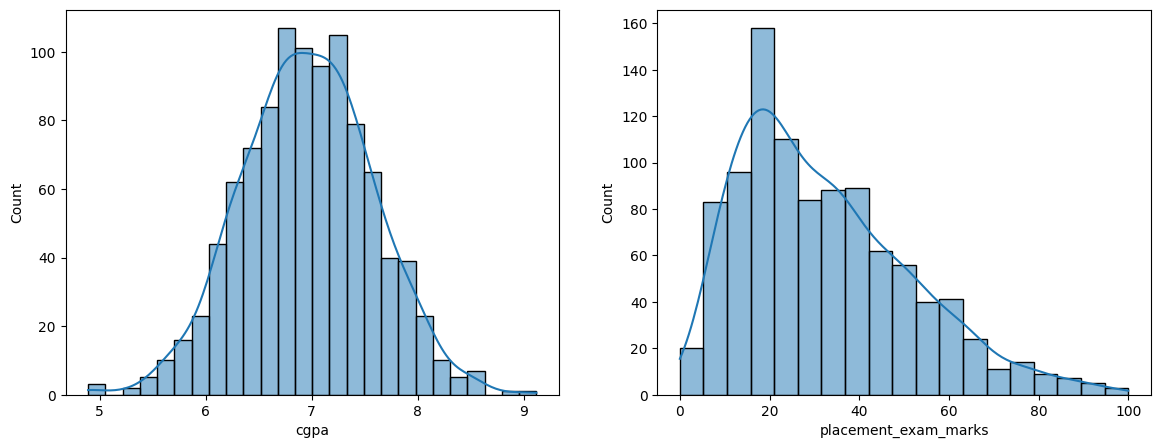

In [7]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.show()

In [9]:
df['cgpa'].skew()
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [10]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

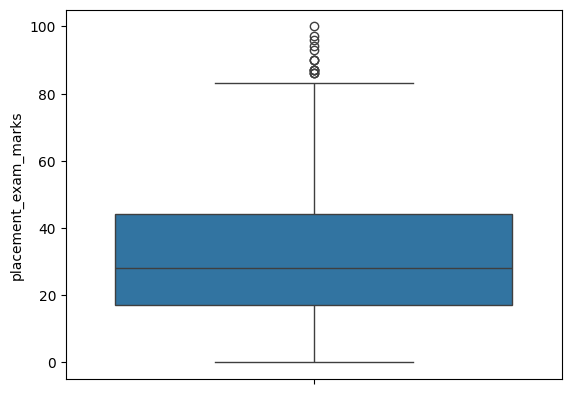

In [11]:
sns.boxplot(df['placement_exam_marks'])

In [14]:
percitile25 = df['placement_exam_marks'].quantile(0.25)
percitile75 = df['placement_exam_marks'].quantile(0.75)
print(percitile25)
print(percitile75)

17.0
44.0


In [15]:
iqr = percitile75 - percitile25
iqr

np.float64(27.0)

In [18]:
upper_limit = percitile75 +1.5 * iqr
print(upper_limit)
lower_limit = percitile25 - 1.5 * iqr
print(lower_limit)

84.5
-23.5


In [22]:
df[df['placement_exam_marks'] > upper_limit].shape

(15, 3)

In [23]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


trimming

In [24]:
new_df = df[(df['placement_exam_marks']< upper_limit) & (df['placement_exam_marks']> lower_limit)]

In [29]:
new_df.shape

(985, 3)

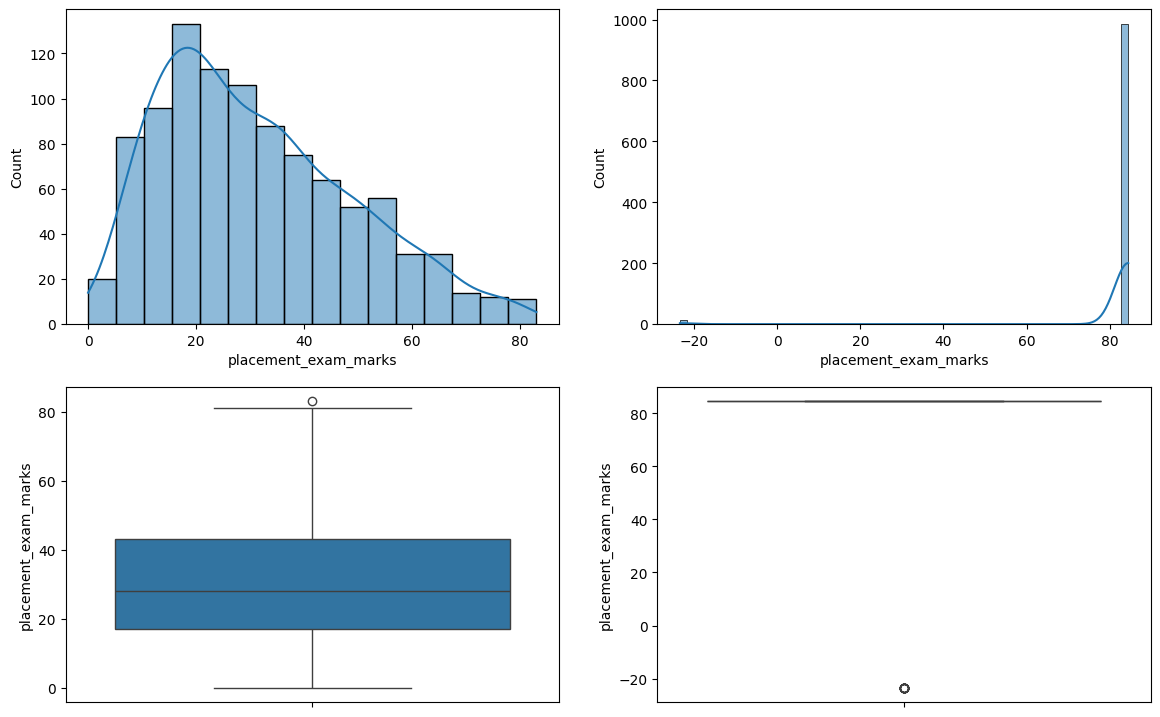

In [49]:
plt.figure(figsize=(14,9))
plt.subplot(2,2,1)
sns.histplot(new_df['placement_exam_marks'],kde=True)
plt.subplot(2,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.subplot(2,2,3)
sns.boxplot(new_df['placement_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(df['placement_exam_marks'])
plt.show()

Capping

In [47]:
cap_df = df.copy()
cap_df['placement_exam_marks'] = np.where(
    df['placement_exam_marks'] < upper_limit,
    upper_limit,
    np.where(
        df['placement_exam_marks'] > lower_limit,
        lower_limit,
        df['placement_exam_marks']
    )
)